In [1]:
#Import required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Pretrained Models Used
models = [
    "BlenderBot_400M",
    "DialoGPT_Medium",
    "FLAN_T5_Base",
    "BlenderBot_1B"
]
# Input Sample
data = {
    "Response_Quality": [7, 6, 8, 9],
    "Speed": [8, 7, 9, 6],
    "Model_Size_MB": [400, 350, 250, 1000],
    "Latency_ms": [300, 250, 180, 450],
    "Ease_of_Use": [8, 9, 8, 6]
}

In [3]:
# Input sample as Dataframe
df = pd.DataFrame(data, index=models)
print("INPUT DATA:\n")
print(df)

INPUT DATA:

                 Response_Quality  Speed  Model_Size_MB  Latency_ms  \
BlenderBot_400M                 7      8            400         300   
DialoGPT_Medium                 6      7            350         250   
FLAN_T5_Base                    8      9            250         180   
BlenderBot_1B                   9      6           1000         450   

                 Ease_of_Use  
BlenderBot_400M            8  
DialoGPT_Medium            9  
FLAN_T5_Base               8  
BlenderBot_1B              6  


In [4]:
# Weights
weights = {
    "Response_Quality": 0.30,
    "Model_Size_MB": 0.15,
    "Speed": 0.20,
    "Latency_ms": 0.20,
    "Ease_of_Use": 0.15
}

In [5]:
# Impacts
impacts = {
    "Response_Quality": "+",
    "Model_Size_MB": "-",
    "Speed": "+",
    "Latency_ms": "-",
    "Ease_of_Use": "+"
}


In [6]:
# Normalized Matrix
normalized_df = df.copy()

for col in df.columns:
    normalized_df[col] = df[col] / np.sqrt((df[col] ** 2).sum())


In [7]:
# Weighted normalizeed matrix
weighted_df = normalized_df.copy()

for col in df.columns:
    weighted_df[col] = normalized_df[col] * weights[col]

In [8]:
# Calculation of Ideal Best & Ideal Worst
ideal_best = []
ideal_worst = []

for col in df.columns:
    if impacts[col] == "+":
        ideal_best.append(weighted_df[col].max())
        ideal_worst.append(weighted_df[col].min())
    else:
        ideal_best.append(weighted_df[col].min())
        ideal_worst.append(weighted_df[col].max())

ideal_best = np.array(ideal_best)
ideal_worst = np.array(ideal_worst)

In [9]:
# Calculate Euclidean Distance
distance_best = []
distance_worst = []

for i in range(len(weighted_df)):
    distance_best.append(np.sqrt(((weighted_df.iloc[i] - ideal_best) ** 2).sum()))
    distance_worst.append(np.sqrt(((weighted_df.iloc[i] - ideal_worst) ** 2).sum()))

In [10]:
# Find TOPSIS score and rank
topsis_score = []

for i in range(len(distance_best)):
    score = distance_worst[i] / (distance_best[i] + distance_worst[i])
    topsis_score.append(score)

result = df.copy()
result["TOPSIS_Score"] = topsis_score
result["Rank"] = result["TOPSIS_Score"].rank(ascending=False)

print("\nFINAL RESULT:\n")
print(result)


FINAL RESULT:

                 Response_Quality  Speed  Model_Size_MB  Latency_ms  \
BlenderBot_400M                 7      8            400         300   
DialoGPT_Medium                 6      7            350         250   
FLAN_T5_Base                    8      9            250         180   
BlenderBot_1B                   9      6           1000         450   

                 Ease_of_Use  TOPSIS_Score  Rank  
BlenderBot_400M            8      0.619588   2.0  
DialoGPT_Medium            9      0.612301   3.0  
FLAN_T5_Base               8      0.866729   1.0  
BlenderBot_1B              6      0.299156   4.0  


In [11]:
# Output to csv file
result.to_csv("topsis_result_conversational.csv")
print("\nResult saved as topsis_result_conversational.csv")



Result saved as topsis_result_conversational.csv


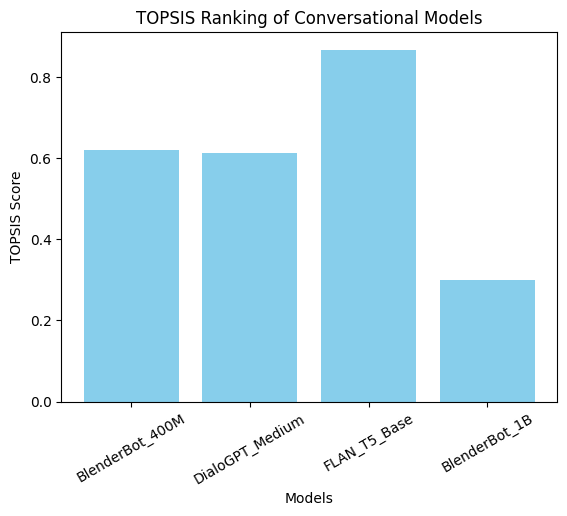

In [13]:
#Comparing different models according to their TOPSIS score
plt.figure()
plt.bar(result.index, result["TOPSIS_Score"],color="skyblue")
plt.xlabel("Models")
plt.ylabel("TOPSIS Score")
plt.title("TOPSIS Ranking of Conversational Models")
plt.xticks(rotation=30)
plt.show()

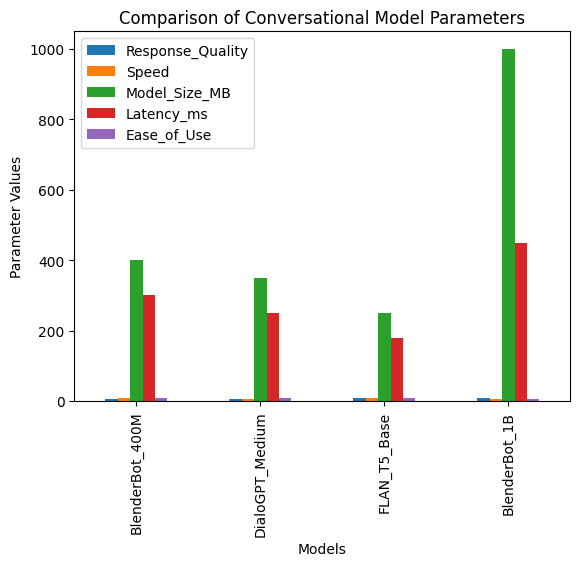

In [14]:
df.plot(kind="bar")
plt.xlabel("Models")
plt.ylabel("Parameter Values")
plt.title("Comparison of Conversational Model Parameters")
plt.show()